# Cramer-Rao Lower Bound (CRLB): Its Meaning, Implications and Calculation
So far, we have established a quite a strong foundation on the DoA estimation problem; we have a couple of algorithms to play with for the target number estimation and arrival angle estimation in a wide variety of scenarios. We also introduced earlier the concept of quantitative performance measurement, along with a lower bound formula. While we assume the idea of crunching some numbers for a more rigorous analysis makes sense to you, you might have reasonable questions on the lower bound function.

We intentionally did not clarify this earlier in order to get your toes into the water first. At this point, we think it is the right time to explain how we get a theoretical boundary below which we can never fall no matter what algorithm we use. This boundary is known as the **Cramér-Rao Lower Bound** (CRLB) and it is highly related to the statistical model we use in this problem. 

We will begin our discussion with a more foundational concept, namely the *Fisher Information Matrix* (FIM), and then build the case with CRLB and its specific use in the DoA estimation problem.

In [1]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 

# np.random.seed(42); # In order to ensure reproducibility. You can use different seed values.

In [2]:
# Defining methods
def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelength: float, ang_unit = "deg") -> np.ndarray:
  if ang_unit == "rad": pass; 
  elif ang_unit == "deg": ang_elev, ang_azim = np.deg2rad(ang_elev), np.deg2rad(ang_azim); 
  else: raise TypeError("Invalid unit for angle values."); 
  
  omega = np.array([np.sin(ang_elev)*np.cos(ang_azim),
                    np.sin(ang_elev)*np.sin(ang_azim),
                    np.cos(ang_elev)]); 
  phase = (2*np.pi/wavelength)*(sensor_pos.T@omega); 
  return np.exp(1j*phase); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelength: float, ang_unit = "deg") -> np.ndarray:
  if ang_unit == "rad": pass; 
  elif ang_unit == "deg": ang_elev, ang_azim = np.deg2rad(ang_elev), np.deg2rad(ang_azim); 
  else: raise TypeError("Invalid unit for angle values."); 

  d_omega = np.array([np.cos(ang_elev) * np.cos(ang_azim),
                      np.cos(ang_elev) * np.sin(ang_azim),
                      -np.sin(ang_elev)]); 
  
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelength, ang_unit = "rad"); 
  d_fac = 1j*(2*np.pi/wavelength)*(sensor_pos.T@d_omega)*(np.pi/180.0); 
  return d_fac * a; 

## Fisher Information

So, what is [Fisher Information](https://en.wikipedia.org/wiki/Fisher_information)? In a few words, it is the way to figure out how much information we can derive about a parameter of interest from a data. It was formulated by [Sir Ronald Aylmer Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher) (hence the name, also check his biography for some spicy information about him) for the asymptotic behavior of the Maximum-Likelihood estimation. 

To understand intuition behind Fisher Information value in statistics and information theory, imagine you are trying to guess a hidden parameter (let's call it $\theta$) based on some observed data. For example, you might be trying to determine the bias of a coin (the parameter) based on a sequence of coin flips (the data).

Every time you flip more coins to collect data, it tells you something about that hidden parameter. But not all data is created equal; some observations give you a lot of certainty, while others leave you guessing. Fisher Information measures the amount of "information" that an observable random variable carries about an unknown parameter. To figure out where the data directs us, we will use *the log-likelihood* function, which tells us the probability of observing our data given different values of the parameter.

$$
\mathcal{L}(\theta ; x) = f(x ; \theta)
\\
\mathcal{l}(\theta ; x) = \log{\mathcal{L}(\theta ; x)} = \log{f(x ; \theta)}
$$

If the log-likelihood function has a very sharp, steep peak around the true parameter, it means small changes in the parameter drastically change the probability of the data. You are highly certain about where the true parameter lies. The curvature at the peak is high. If the log-likelihood function is wide and flat, changing the parameter doesn't change the probability of the data very much. You have a lot of uncertainty. The curvature at the peak is low.

In short: *Fisher Information* is a measure of the curvature of the log-likelihood function. The sharper the curve, the higher the Fisher Information. Because we are often dealing with multiple parameters at once (a vector $\mathbf{\theta}$), we use a matrix to capture the curvature in all dimensions and the interactions between parameters. This is the *Fisher Information Matrix* (FIM).

### Derivation of Fisher Information Matrix

Let's move from the intuition to the formal mathematical description. Assume $\mathbf{X}$ is our data, a random variable drawn from a probability distribution defined by a *probability mass function* (pmf) $f(\mathbf{X} ; \mathbf{\theta})$. Here, $\mathbf{\theta}={[\theta_{1}​,\theta_{2}​, \cdots, \theta_{k}​]}^T$ is a vector of $k$ unknown parameters.

The likelihood of a specific parameter vector θ given an observation x is L(θ;x)=f(x;θ). Because probabilities multiply and can result in infinitesimally small numbers, it is mathematically easier to work with *the log-likelihood function* (logarithmic algebra also gives us useful properties when dealing with a ton of multiplications, divisions, and powers, as is the case with probability and statistics):

$$\mathcal{l}(\theta ; x) = \log(f(\mathbf{X} ; \mathbf{\theta}))$$

Now, we need to know how sensitive the log-likelihood is to changes in the parameters. We can find it by taking the partial derivative of the log-likelihood with respect to $\theta$. This is known as *the score function*, denoted as $\mathbf{V}$.

$$\mathbf{V} = \nabla_{θ}​\log (f(\mathbf{X} ; \mathbf{\theta})) \in \mathbb{R}^{k}$$

where the $i$-th component of the score vector is:

$$V_{i} ​= \frac{​\partial \log {f(X;θ)}}{\partial {θ_{i}}} $$

the expected value of the score evaluated at the true parameter value is exactly zero. That is, $\mathbb{E}[\mathbf{V}]=\mathbf{0}$. On average, the gradient of the log-likelihood at the true parameter points nowhere; it is at the peak. When this is the case, the gradient of the log-likelihood at the true parameter points nowhere; it is at the peak.

Since the expected value of the score is zero, the variance of the score is simply the expected value of the score multiplied by itself (its outer product). The Fisher Information Matrix, I(θ), is defined as the covariance matrix of the score function.

$$\mathbf{I}(\mathbf{\theta})=\mathbb{E}[\mathbf{V}\mathbf{V}^T]$$

Element-wise, the matrix is defined as:

$$\mathbf{I}(θ)_{i,j} ​= \mathbb{E}[(\frac{\partial}{\partial\theta_{i}}​\log(f(\mathbf{X} ; \mathbf{\theta}))) (\frac{\partial}{\partial\theta_{j}}​\log(f(\mathbf{X} ; \mathbf{\theta})))]$$

### The Hessian Equivalence

Remember in the intuition that we were interested in the curvature of the peak. The formal definition above measures *variance*, but under standard regularity conditions (specifically, that we can swap the order of integration and differentiation), the FIM can be rewritten as the negative expected value of the second derivative ([*the Hessian matrix*](https://en.wikipedia.org/wiki/Hessian_matrix)) of the log-likelihood:

$$\mathbf{I}(\mathbf{\theta})_{i,j} ​= −\mathbb{E}[\frac{\partial^2}{\partial\theta_{i}\partial\theta_{j}} ​\log (f(\mathbf{X};\mathbf{\theta}))]$$

and in matrix notation it becomes:

$$ \mathbf{I}(θ) = −\mathbb{E}[\nabla^{2}_{\mathbf{\theta}} ​log (f(\mathbf{X} ; \mathbf{\theta}))] $$

This perfectly aligns with our intuition: the second derivative measures curvature. A highly negative expected second derivative (a very sharp peak) results in a large positive Fisher Information.

The Fisher Information Matrix is a foundational concept that bridges statistics, information theory. If you want to iterate over the concept of FIM in a different medium and missed the videos for this topic in the earlier notebooks, check out the YouTube video [The Fisher Information](https://www.youtube.com/watch?v=pneluWj-U-o) by Mutual Information.

## Cramér-Rao Lower Bound (CRLB)
The *Cramér-Rao Lower Bound* (CRLB), our main interest, is perhaps the most famous application of the FIM. CRLB answers a fundamental question in statistical estimation: What is the absolute best performance we can expect from an unbiased estimator? The bound was independently discovered in the mid-1940s by the Swedish mathematician [Harald Cramér](https://en.wikipedia.org/wiki/Harald_Cram%C3%A9r) (1946) and the Indian statistician [C.R.Rao](https://en.wikipedia.org/wiki/C._R._Rao) (1945) (therefore the value is named after two of them).

The CRLB and Fisher Information are inverse mathematical reflections of one another. For an analogy, if Fisher Information ($\mathbf{I}(\theta)$) measures the amount of "light" your data shines on an unknown parameter, the CRLB defines the minimum amount of "blurriness" (variance) you are stuck with when guessing that parameter.

For a single parameter $\theta$ and an *unbiased estimator* $\hat{\theta}$, the relationship is reciprocal. For a vector of parameters $\hat{\mathbf{\theta}}$, the relationship scales into matrix algebra.

$$
Var(\hat{\theta}) \ge \frac{1}{\mathbf{I}(\theta)​}
\\
Cov(\hat{\mathbf{\theta}}) \ge \mathbf{I}(\mathbf{\theta})^{-1}
$$

Let's derive the bound for a single parameter $\theta$. We will be reminded that $\mathbf{X}$ is our data with probability density function $f(\mathbf{X} ; \theta)$. Let $\hat{\theta}(\mathbf{X})$ be an unbiased estimator of $\theta$. By definition of unbiasedness, its expected value is exactly $\theta$:

$$
\mathbb{E}[\hat{\theta}(\mathbf{X})]= \int \hat{\theta}(\mathbf{X}) f(\mathbf{X} ; \theta) dx = \theta
$$

Now, differentiate both sides of this equation with respect to θ, and then pass the derivative inside the integral:

$$
\begin{aligned}
\frac{\partial}{\partial\theta} \int \hat{\theta}(\mathbf{X}) f(\mathbf{X} ; \theta) dx &= \frac{\partial}{\partial\theta} ​\theta=1
\\
\int \hat{\theta}(\mathbf{X}) \frac{\partial}{\partial\theta} f(\mathbf{X} ; \theta) ​dx &= 1
\end{aligned}
$$

We use the calculus identity $\frac{\partial\log(g)}{\partial\theta} ​= \frac{1}{g} {\partial g}/{\partial \theta}$, which means ${\partial f}/{\partial \theta} = f(\mathbf{X} ; \theta) {\partial \log f(\mathbf{X} ; \theta)}/{\partial \theta}$​ ​. Substituting this back in gives:

$$\int \hat{\theta}(\mathbf{X})(\frac{\partial}{\partial\theta} \log f(\mathbf{X} ; \theta)​) f(\mathbf{X} ; \theta) dx = 1$$

This integral is simply an expectation of a function of an RV. Recall that the term in the parenthesis is the score function, $\mathbf{V}(\mathbf{X})$. Therefore:

$$\mathbb{E}[\hat{\theta}(\mathbf{X})\mathbf{V}(\mathbf{X})] = 1$$

We know from the properties of Fisher Information that the expected value of the score function is zero: $\mathbb{E}[\mathbf{V}(\mathbf{X})]=0$. This allows us to rewrite the equation above as a covariance.

$$
Cov(\hat{\theta}(\mathbf{X}),\mathbf{V}(\mathbf{X})) = \mathbb{E}[\hat{\theta}(\mathbf{X})\mathbf{V}(\mathbf{X})] − \mathbb{E}[\hat{\theta}(\mathbf{X})] \mathbb{E}[\mathbf{V}(\mathbf{X})] = 1 − 0 = 1
$$

[*The Cauchy-Schwarz Inequality*](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Schwarz_inequality) states that for any two random variables, the square of their covariance is less than or equal to the product of their variances.

$$[Cov(\hat{\theta}(\mathbf{X}),\mathbf{V}(\mathbf{X}))]^2 \le Var(\hat{\theta}(\mathbf{X})) \cdot Var(\mathbf{V}(\mathbf{X}))$$

Plugging in the pieces we know:

$$
\begin{aligned}
Cov(\hat{\theta}(\mathbf{X}),\mathbf{V}(\mathbf{X})) &= 1
\\
Var(\mathbf{V}(\mathbf{X})) &= \mathbf{I}(\mathbf{\theta})
\end{aligned}
$$

$$ 1^2 \le Var(\hat{\theta}(\mathbf{X})) \cdot \mathbf{I}(\mathbf{\theta})$$

Dividing both sides by I(θ) yields the Cramér-Rao Lower Bound:

$$Var(\hat{\theta}(\mathbf{X})) \ge \frac{1}{\mathbf{I}(\mathbf{\theta})}$$

An unbiased estimator that exactly hits the CRLB is called *efficient*. If an efficient estimator exists, it is automatically the *Minimum Variance Unbiased Estimator* (MVUE). Not all problems have an estimator that hits the CRLB for small sample sizes. However, under mild conditions, *Maximum-Likelihood Estimators* (MLEs) are asymptotically efficient. This means as your sample size $n → \infty$, the variance of your MLE will perfectly converge to the CRLB.

### CRLB in DoA Estimation

In the late 1980s and early 1990s, [Peter Stoica](https://en.wikipedia.org/wiki/Peter_Stoica) and [Arye Nehorai](https://en.wikipedia.org/wiki/Arye_Nehorai) published a series of foundational papers on the statistical analysis of available DoA estimation methods. Before their work, the field focused heavily on proposing heuristic algorithms for finding arrival angles. Stoica and Nehorai shifted the field toward rigorous statistical benchmarks by establishing exactly how much information an array of sensors can extract from incoming wavefields.

They define two distinct statistical methods for the problem.

* **Conditional Model** (CM): This is the statistic model that treats the signal as one instance selected from a random process following Gaussian distribution (Rayleigh fading model).
* **Unconditional Model** (UM): This is the statistical model that assumes independent random processes.

If you pay attention, the CM's target signal is not a structured signal; our assumptions on the target still follows the Rayleigh fading model. What makes the conditional model different than the unconditional model is that in CM we work with one sample from the random Gaussian process, whereas in UM works with a random sampling each time.

### Signal Model Reminder

We will first remind us the model and the parameters. Assume $K$ narrow-band plane waves impinge on an array of $N$ sensors ($N$ > $K$). The received vector at time snapshot $t$ (for $t=1,\cdots,T$) is modeled as:

$$
\mathbf{x}(t) = \mathbf{A} \mathbf{s}(t) + \boldsymbol{\eta}(t)
$$

* $\mathbf{x}(t) \in \mathbb{C}^{N}$ is the observed data vector.

* $\boldsymbol{\theta} = [\theta_{1}​,\theta_{2}​,\cdots,\theta_{K}​]^T \in \mathbb{R}^{K}$ is the vector of unknown DoAs.

* $\mathbf{A} = [\mathbf{a}(\boldsymbol{\theta}_{1}), \cdots, \mathbf{a}(\boldsymbol{\theta}_{K}​)] \in \mathbb{C}^{K \times N}$ is the array steering matrix. For $\mathbf{\omega}_{k} = [sin(\theta_k)cos(\phi_k), sin(\theta_k)sin(\phi_k), cos(\phi_k)]^T \in \mathbb{R}^{3 \times 1}$ (all azimuth angles assumed to be $\phi_{k} = 0$):

$$
\mathbf{a}(\boldsymbol{\theta}_{k}) = \left[ e^{j {\mathbf{p}_{1}}^T \mathbf{\omega}_{k}}, \dots, e^{j {\mathbf{p}_{N}}^T \mathbf{\omega}_{k}} \right]^{T} \in \mathbb{C}^{N}
\\
\mathbf{A} = \left[\mathbf{a}(\boldsymbol{\theta}_1), \dots, \mathbf{a}(\boldsymbol{\theta}_K) \right] \in \mathbb{C}^{N \times K}
$$

* $\mathbf{s}(t) \in \mathbb{C}^{K}$ is the complex signal vector at snapshot $t$.

* $\mathbf{\eta}(t) \in \mathbb{C}^{N}$ is additive zero-mean complex circular white Gaussian noise, where $\mathbb{E}[\mathbf{\eta}(t) \mathbf{\eta}^{H}(t)] = \sigma_{\eta}^{2} \mathbf{I} \delta_{t,s}$​.

On top of this, we will also define the derivative of the antenna steering vector $\mathbf{D} \in \mathbb{C}^{K \times N}$:

$$
\mathbf{D} = [\mathbf{d}(\theta_{1}), \cdots, \mathbf{d}(\theta_{n})] 
\\
\mathbf{d}(\theta_{k}) = \frac{\partial \mathbf{a}(\omega_{k})}{\partial \omega_{k}}=  \left[j\mathbf{p}_{1}e^{j {\mathbf{p}_{1}}^T \mathbf{\omega}_{k}}, \cdots, j\mathbf{p}_{K} e^{j {\mathbf{p}_{N}}^T \mathbf{\omega}_{k}} \right]^{T}
$$


Under the conditional model, the parameters to estimate are the arrival angles $\mathbf{\theta}$, the real and imaginary parts of the signals $\mathbf{s}(t)$ for all $T$ snapshots, and the noise variance $\sigma_{\eta}^{2}$.

Since the noise is temporally white and complex Gaussian, the joint probability density function across all $N$ snapshots is the product of independent Gaussians. *The log-likelihood function* $\mathcal{L}$ (ignoring constant terms) is:

$$
\mathcal{L}(\mathbf{\theta},\mathbf{s},\sigma_{\eta}^{2}) = −mN\log(\sigma_{\eta}^{2}) − \frac{1}{\sigma_{\eta}^{2}} \sum_{t=1}^{T} ​∥\mathbf{x}(t) − \mathbf{A}(\mathbf{\theta})\mathbf{s}(t)∥^2
$$

### FIM Calculation

For complex deterministic signals in complex Gaussian noise, we can evaluate the FIM matrix corresponding to the mean parameters using a variant of the Slepian-Bangs formula.

Let the vector of mean values be $\boldsymbol{\mu}(t) = \mathbf{A} \mathbf{s}(t)$. The cross-terms between $\sigma_{\eta}^{2}$ and the spatial/signal parameters evaluate to zero in expectation, so $\sigma_{\eta}^{2}$ uncouples from the rest of the matrix. We focus on the parameters $\mathbf{\theta}$ and $\mathbf{s}(t)$.

Let's compute the partial derivatives of $\boldsymbol{\mu}(t)$:

With respect to $\theta_{k}$​:

$$
\frac{\partial \boldsymbol{\mu}(t)}{\partial \theta_{k}} = \frac{\partial \mathbf{a}(\theta_{k})}{\partial \theta_{k}} x_{k}(t) = \mathbf{d}(\theta_{k}) x_{k}(t)
$$

If we define the matrix $\mathbf{X}(t) = \text{diag}(\mathbf{x}(t))$, then:

$$
\frac{\partial \boldsymbol{\mu}(t)}{\partial \boldsymbol{\theta}} = \mathbf{D}\mathbf{X}(t)
$$

With respect to the signal $\mathbf{x}(t)$:

$$
\frac{\partial \boldsymbol{\mu}(t)}{\partial \mathbf{x}(t)} = \mathbf{A}
$$

The full FIM for the spatial and signal parameters across all snapshots forms a large block matrix:

$$
\mathbf{J} = \begin{bmatrix} \mathbf{J}_{\boldsymbol{\theta}\boldsymbol{\theta}} & \mathbf{J}_{\boldsymbol{\theta}\mathbf{x}} \\ \mathbf{J}_{\mathbf{x}\boldsymbol{\theta}} & \mathbf{J}_{\mathbf{x}\mathbf{x}} \end{bmatrix}
$$

We are only interested in the lower bound for the DOA parameters $\boldsymbol{\theta}$. To isolate it, we compute the [Schur complement](https://en.wikipedia.org/wiki/Schur_complement) of the block matrix, which effectively subtracts the information lost due to having to estimate the nuisance signal parameters $\mathbf{x}(t)$:

$$
\mathbf{J}_{\boldsymbol{\theta}} = \mathbf{J}_{\boldsymbol{\theta}\boldsymbol{\theta}} - \mathbf{J}_{\boldsymbol{\theta}\mathbf{x}} \mathbf{J}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{J}_{\mathbf{x}\boldsymbol{\theta}}
$$

Stoica and Nehorai provided a powerful geometric insight for this step: estimating the nuisance parameters $\mathbf{x}(t)$ is algebraically equivalent to projecting the steering matrix derivatives onto the subspace orthogonal to the steering matrix $\mathbf{A}$.

Let $\mathbf{P}_\mathbf{A} = \mathbf{A}(\mathbf{A}^H \mathbf{A})^{-1}\mathbf{A}^H$ be the orthogonal projection matrix onto the column space of $\mathbf{A}$, and let $\mathbf{P}_\mathbf{A}^\perp = \mathbf{I} - \mathbf{P}_\mathbf{A}$ be the projection onto the orthogonal complement (the noise subspace). Applying this projection, the concentrated information matrix for $\boldsymbol{\theta}$ simplifies to:

$$\mathbf{J}_{\boldsymbol{\theta}} = \frac{2}{\sigma_{\eta}^{2}} \sum_{t=1}^N \text{Re} \left\{ \mathbf{X}^H(t) \mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D} \mathbf{X}(t) \right\}$$

We can rewrite the expression inside the summation. Notice that the $(i,j)$-th element of the matrix $\mathbf{X}^H(t) \mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D} \mathbf{X}(t)$ is given by:

$$
x_i^*(t) [\mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D}]_{i,j} x_j(t) = [\mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D}]_{i,j} \cdot [ \mathbf{x}(t)\mathbf{x}^H(t) ]_{j,i}
$$

When we sum this over all $N$ snapshots, the term $\frac{1}{N}\sum_{t=1}^N \mathbf{x}(t)\mathbf{x}^H(t)$ becomes the sample covariance matrix of the source signals, denoted as $\hat{\mathbf{R}}_{xx}$. Using the Hadamard product ($\odot$, representing element-wise multiplication), Stoica and Nehorai compressed the entire summation into a single line:

$$
\mathbf{J}_{\boldsymbol{\theta}} = \frac{2N}{\sigma_{\eta}^{2}} \text{Re} \left\{ (\mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D}) \odot \hat{\mathbf{R}}_{xx}^T \right\}
$$

Inverting this information matrix yields the long-awaited Stoica-Nehorai Conditional CRLB formula:

$$
\text{CRLB}_{CM}(\boldsymbol{\theta}) = \frac{\sigma_{\eta}^{2}}{2N} \left[ \text{Re} \left\{ (\mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D}) \odot \hat{\mathbf{R}}_{xx}^T \right\} \right]^{-1}
$$

In their 1990 paper, they applied a similar workflow to the Unconditional Model, where the data covariance is $\mathbf{R}_{xx} = \mathbf{A}\mathbf{P}\mathbf{A}^H + \sigma_{\eta}^{2}\mathbf{I}$, to yield the stochastic bound: 

$$
\text{CRLB}_{UM}(\boldsymbol{\theta}) = \frac{\sigma_{\eta}^{2}}{2N} \left[ \text{Re} \left\{ (\mathbf{D}^H \mathbf{P}_\mathbf{A}^\perp \mathbf{D}) \odot (\mathbf{P}\mathbf{A}^H\mathbf{R}_{xx}^{-1}\mathbf{A}\mathbf{P})^T \right\} \right]^{-1}
$$

## Implementation
That was such a derivation, ain't it? Unfortunately, we had to go through it all in order to really understand why we have such a lower bound and how it relates to the specific problem we are solving. While it may take some time for you to go over the definitions and derivations, once it clicks you will see the utility of such a metric.

If you are ready to move on, however, you can analyze the implementation of Stochastic Unconditional CRLB that follows the very last equation in the previous derivation.

In [3]:
def calculate_stochastic_crb(
    sensor_pos: np.ndarray, 
    angs_azim: np.ndarray, 
    angs_elev: np.ndarray, 
    snr_db: float, 
    S_db: list[float],
    wl: float, 
    T: int
    ) -> np.ndarray:
  N = sensor_pos.shape[1]; 
  K = len(angs_elev); 

  noise_pow = 10**(-snr_db / 10); 
  sig_pow = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]);  # S_db should be a list or array of signal powers in dB
   
  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A = np.column_stack([steering_vector(sensor_pos, th, ph, wl) for [ph, th] in zip(angs_azim, angs_elev)]); 
  D_mat = np.column_stack([d_steering_vector(sensor_pos,th, ph, wl) for [ph, th] in zip(angs_azim, angs_elev)]); 
  
  R_ss = sig_pow @ np.eye(K); # np.diag(np.array(sig_pow)) 
  
  Rxx_true = A @ R_ss @ A.conj().T + noise_pow * np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 
  
  # Projection matrix onto the noise subspace
  P_A_perp = np.eye(N) - A @ np.linalg.inv(A.conj().T @ A) @ A.conj().T; 
  
  # Fisher Information Matrix (FIM)
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A.conj().T @ Rxx_inv @ A @ R_ss).T; 
  
  FIM = (2*T/noise_pow) * np.real(term1 * term2); 
  
  return np.linalg.inv(FIM); 

## Parameters
As we are done implementing the CRLB, let's define the parameters for this notebook.

* $c$: Speed of light. Assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz. We will stick to using $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters, which is calculated as $\lambda = \frac{c}{f} = 6\text{ cm}$.

Next step is to determine the ULA parameters.

* $N$: # of antenna elements. As always, we will choose $16$.
* $T$: # of snapshots. As a generic number, we will go with $1000$.
* $K$: # of targets. It will be $2$ for this notebook.

In [4]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Target carrier frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 100;        # Number of snapshots
K = 2;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -80;  # Minimum elevation angle (deg)
ang_max = 80;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 1     # Angular resolution in scanning (deg)

### CRLB per SNR

Let's put the CRLB formula into work! We will first test the boundary for different SNR values. As we increase the SNR value, we expect to get a lower CRLB score. Let's see if our assumption will hold true when we put the formula into work.

Below is a script that calculates CRLB for $K=2$, with targets located between the angle interval $[-60 \degree, 60 \degree]$ and separated by a minimum $5 \degree$. The snapshot number is fixed to be $T=1000$.

Remember: each unique parameters have their own CRLB, this includes the number of target angles and distinct target angles themselves. For this reason, computing CRLB even for a single SNR value is a rather hefty calculation, so we are using a range with $5$ increments between $-20$ and $20\text{ dB}$. However, we highly encourage you to try different SNR ranges with more resolution if you have the time for the processing.

In [5]:
sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position

# Sweep arrays
snr_db_range = np.arange(-20, 21, 5);                                   # SNR range from -20 dB to 20 dB
th1_scan = np.arange(ang_min, ang_max+ang_res-ang_dist ,ang_res);       # First target scan

crb_per_snr = []; 

for snr_db in snr_db_range: 
  print(f"Calculating SNR: {snr_db} dB"); 
  # Array to store the results
  crb_vals = []; 
  for th1 in th1_scan: 

    th2_scan = np.arange(th1+ang_dist, ang_max+ang_res, ang_res); 
    for th2 in th2_scan: 
      angs_azim = [0]*K; 
      angs_elev = [th1, th2]; 
        
      # Calculate the CRB matrix
      crb_mat = calculate_stochastic_crb(sensor_pos, angs_azim, angs_elev, snr_db, S_db, wl, T);  
      crb_vals.append(np.trace(crb_mat)/K); 
            
  crb_vals = np.array(crb_vals); 
  print(f"Calculation completed for SNR: {snr_db} dB"); 
  crb_per_snr.append(crb_vals); 

crb_per_snr = np.array(crb_per_snr); 
rmse_per_snr = np.sqrt(crb_per_snr); 

Calculating SNR: -20 dB
Calculation completed for SNR: -20 dB
Calculating SNR: -15 dB
Calculation completed for SNR: -15 dB
Calculating SNR: -10 dB
Calculation completed for SNR: -10 dB
Calculating SNR: -5 dB
Calculation completed for SNR: -5 dB
Calculating SNR: 0 dB
Calculation completed for SNR: 0 dB
Calculating SNR: 5 dB
Calculation completed for SNR: 5 dB
Calculating SNR: 10 dB
Calculation completed for SNR: 10 dB
Calculating SNR: 15 dB
Calculation completed for SNR: 15 dB
Calculating SNR: 20 dB
Calculation completed for SNR: 20 dB


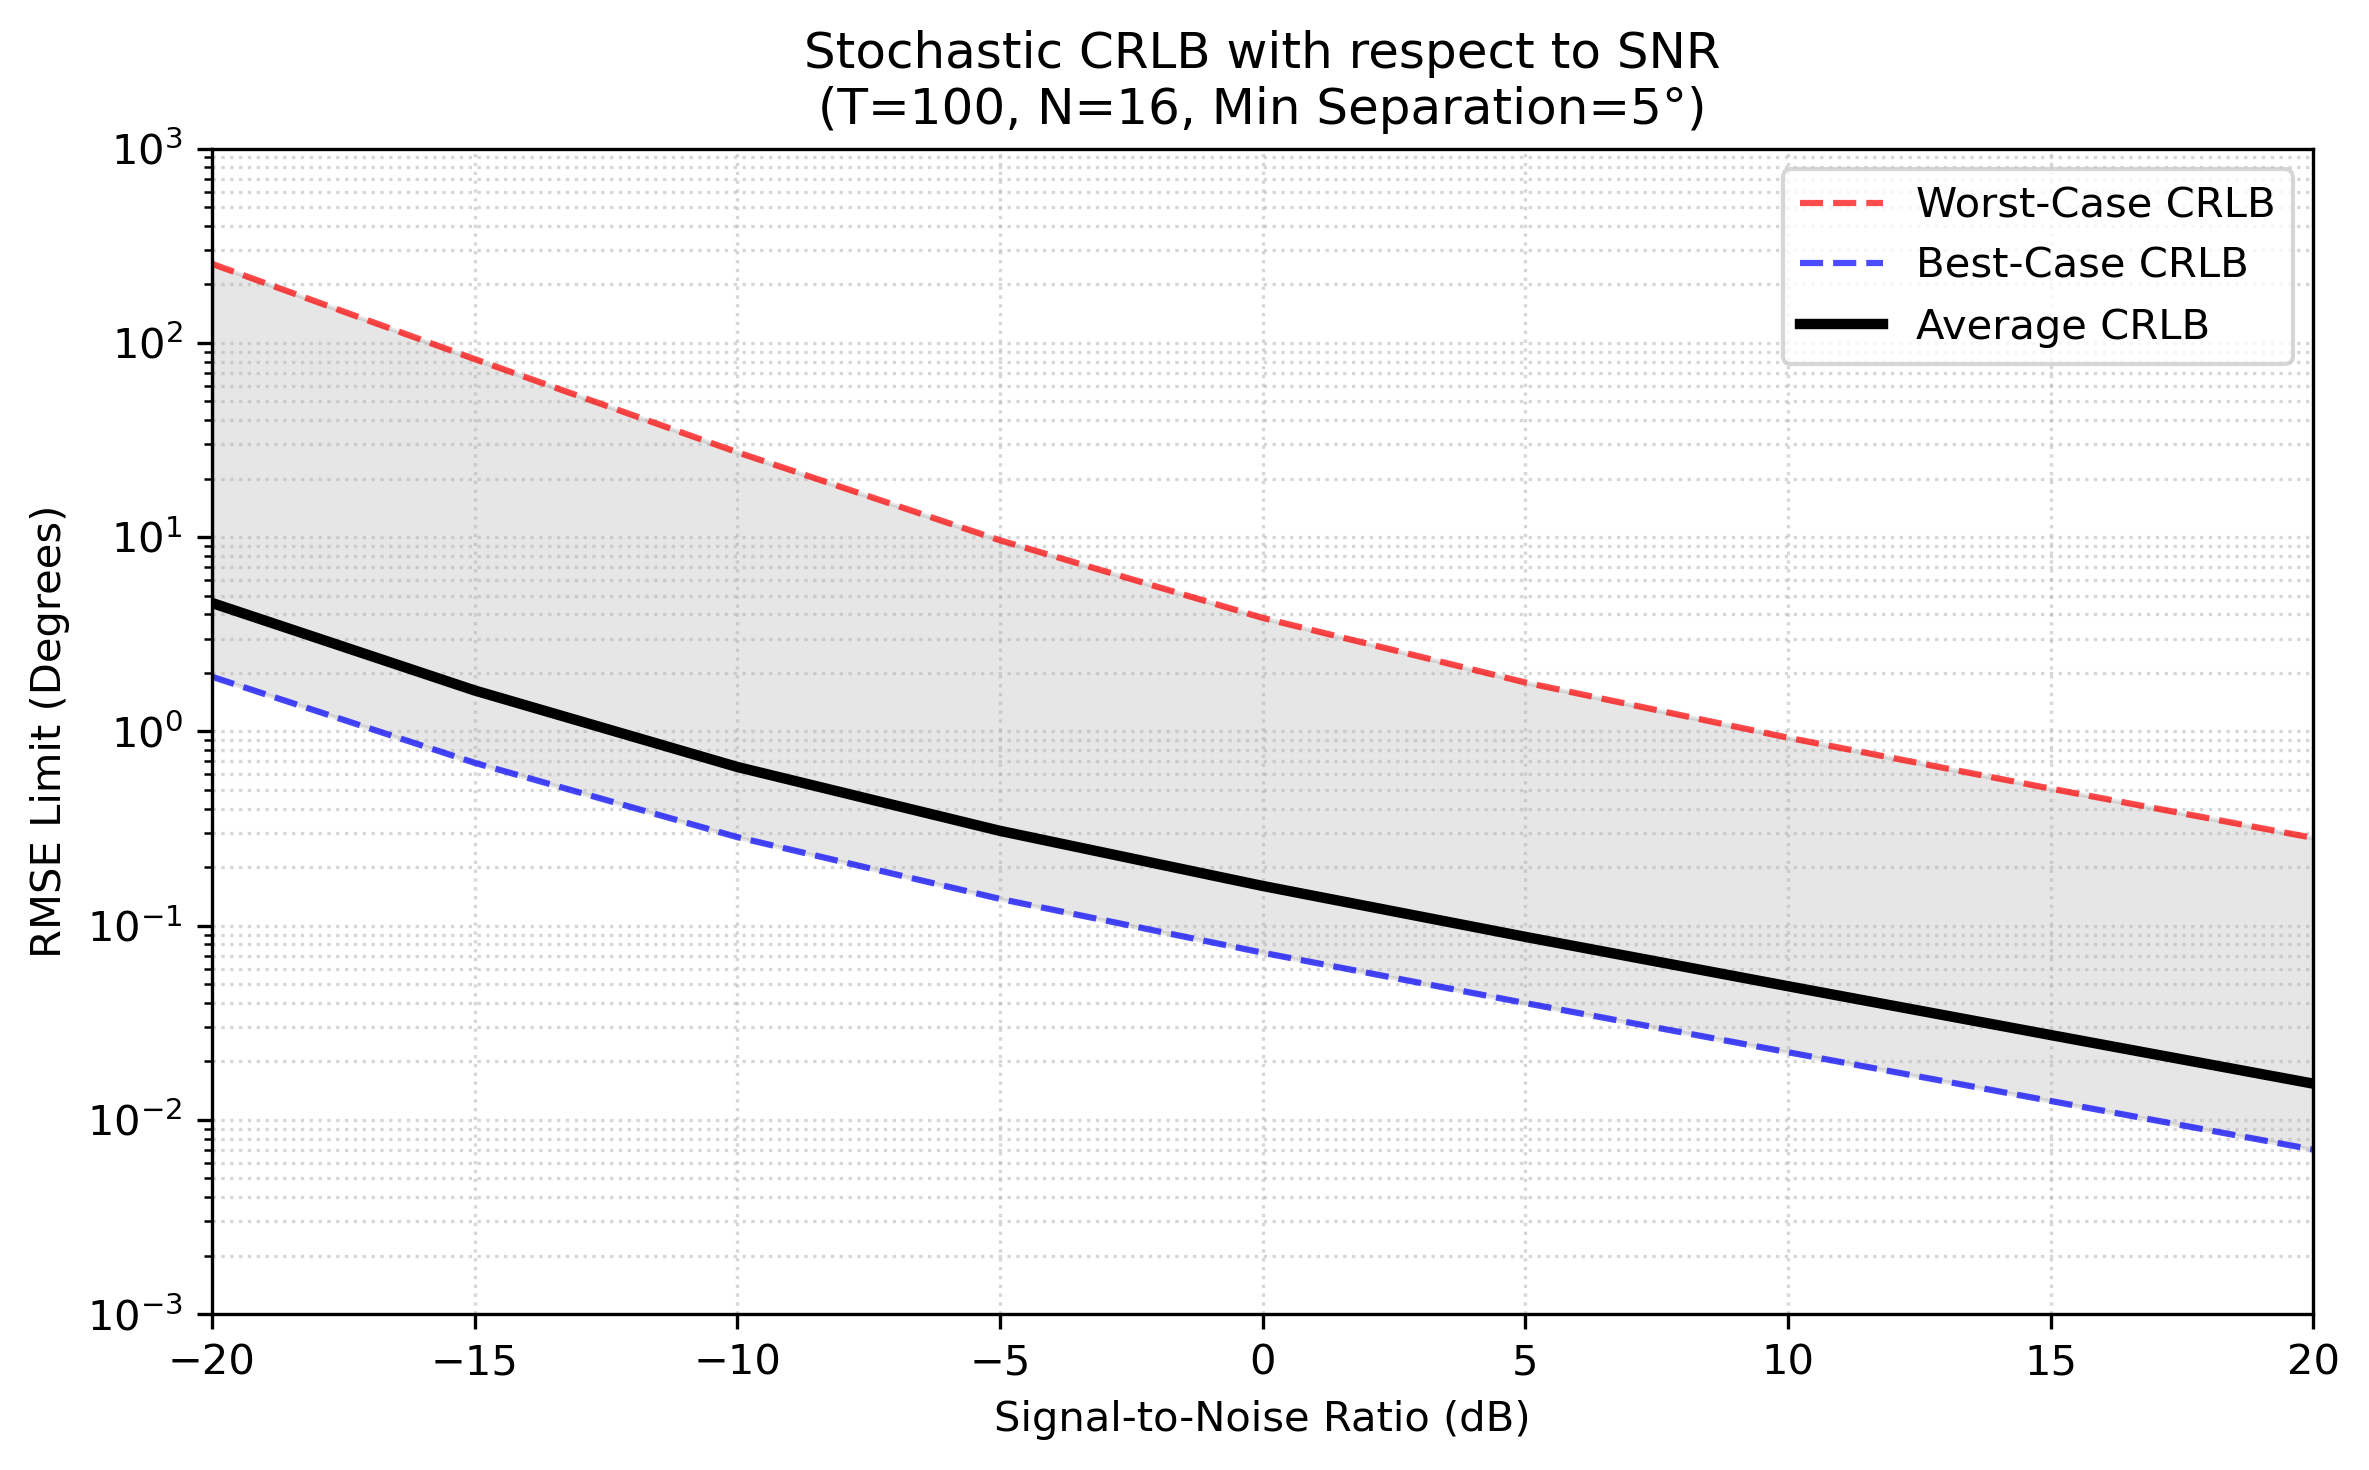

In [6]:
plt.figure(figsize=(8, 5), dpi=300); 

best_case_rmse = np.min(rmse_per_snr, axis=1); 
worst_case_rmse = np.max(rmse_per_snr, axis=1); 
average_rmse = np.mean(rmse_per_snr, axis=1); 
#average_rmse = np.sqrt(np.mean(crb_per_snr, axis=1)); 
variance_rmse = np.sqrt(np.var(crb_per_snr, axis=1)); 

plt.semilogy(snr_db_range, worst_case_rmse, 'r--', linewidth=1.5, label='Worst-Case CRLB', alpha=0.7); 
plt.semilogy(snr_db_range, best_case_rmse, 'b--', linewidth=1.5, label='Best-Case CRLB', alpha=0.7); 
plt.semilogy(snr_db_range, average_rmse, 'k-', linewidth=2.5, label='Average CRLB'); 

# Visualization with a gradient area
for alpha_val in np.linspace(0.05, 0.3, 10):        # Gradient effect for the area in between
  plt.fill_between(snr_db_range, best_case_rmse, worst_case_rmse, color='gray', alpha=alpha_val/10); 

#plt.boxplot(rmse_per_snr.T, positions=snr_db_range, widths=1.0, 
#            patch_artist=True, showfliers=False, 
#            boxprops=dict(facecolor='white', color='black', alpha=0.6),
#            medianprops=dict(color='orange', linewidth=2)); 

plt.title(f'Stochastic CRLB with respect to SNR\n(T={T}, N={N}, Min Separation={ang_dist}°)'); 
plt.xlim([-20,20]); plt.ylim([0.001, 1000]); 
plt.xlabel('Signal-to-Noise Ratio (dB)'); plt.ylabel('RMSE Limit (Degrees)'); 
plt.grid(True, which="both", ls=":", alpha=0.5); 
plt.legend(loc='upper right'); 
plt.tight_layout(); 
plt.show(); 

The figure above prints the whole range of CRLB for all available targets at a given SNR value, bounded by the largest value (worst-case) and the lowest one (best-case). As expected, CRLB drops with increase in SNR, and this drop rate follows a fairly linear-like trend.

### CRLB Per Snapshot

Like the case with SNR, more snapshots should intuitively give us better performance, therefore we expect lower CRLB with higher values of $T$. With the same setup used in the previous case, we will calculate CRLB for a range of snapshots, from $100$ to $1000$ with increments of $50$. This time, the SNR value is fixed to $10 \text{ dB}$.

In [7]:
sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position

# Sweep arrays
snr_db = 10.; 
snapshot_range = np.arange(100, 1001, 50);                              # SNR from -10 dB to 20 dB
th1_scan = np.arange(ang_min, ang_max+ang_res-ang_dist ,ang_res);       # First target scan

crb_per_t = []; 

for snapshot in snapshot_range: 
  print(f"Calculating T: {snapshot}"); 
  # Array to store the results
  crb_vals = []; 
  for th1 in th1_scan: 

    th2_scan = np.arange(th1+ang_dist, ang_max+ang_res, ang_res); 
    for th2 in th2_scan: 
      angs_azim = [0]*K; 
      angs_elev = [th1, th2]; 
        
      # Calculate the CRB matrix
      crb_mat = calculate_stochastic_crb(sensor_pos, angs_azim, angs_elev, snr_db, S_db, wl, snapshot);  
      crb_vals.append(np.trace(crb_mat)/K); 
            
  crb_vals = np.array(crb_vals); 
  print(f"Calculation completed for T: {snapshot}"); 
  crb_per_t.append(crb_vals); 

crb_per_t = np.array(crb_per_t); 
rmse_per_t = np.sqrt(crb_per_t); 

Calculating T: 100
Calculation completed for T: 100
Calculating T: 150
Calculation completed for T: 150
Calculating T: 200
Calculation completed for T: 200
Calculating T: 250
Calculation completed for T: 250
Calculating T: 300
Calculation completed for T: 300
Calculating T: 350
Calculation completed for T: 350
Calculating T: 400
Calculation completed for T: 400
Calculating T: 450
Calculation completed for T: 450
Calculating T: 500
Calculation completed for T: 500
Calculating T: 550
Calculation completed for T: 550
Calculating T: 600
Calculation completed for T: 600
Calculating T: 650
Calculation completed for T: 650
Calculating T: 700
Calculation completed for T: 700
Calculating T: 750
Calculation completed for T: 750
Calculating T: 800
Calculation completed for T: 800
Calculating T: 850
Calculation completed for T: 850
Calculating T: 900
Calculation completed for T: 900
Calculating T: 950
Calculation completed for T: 950
Calculating T: 1000
Calculation completed for T: 1000


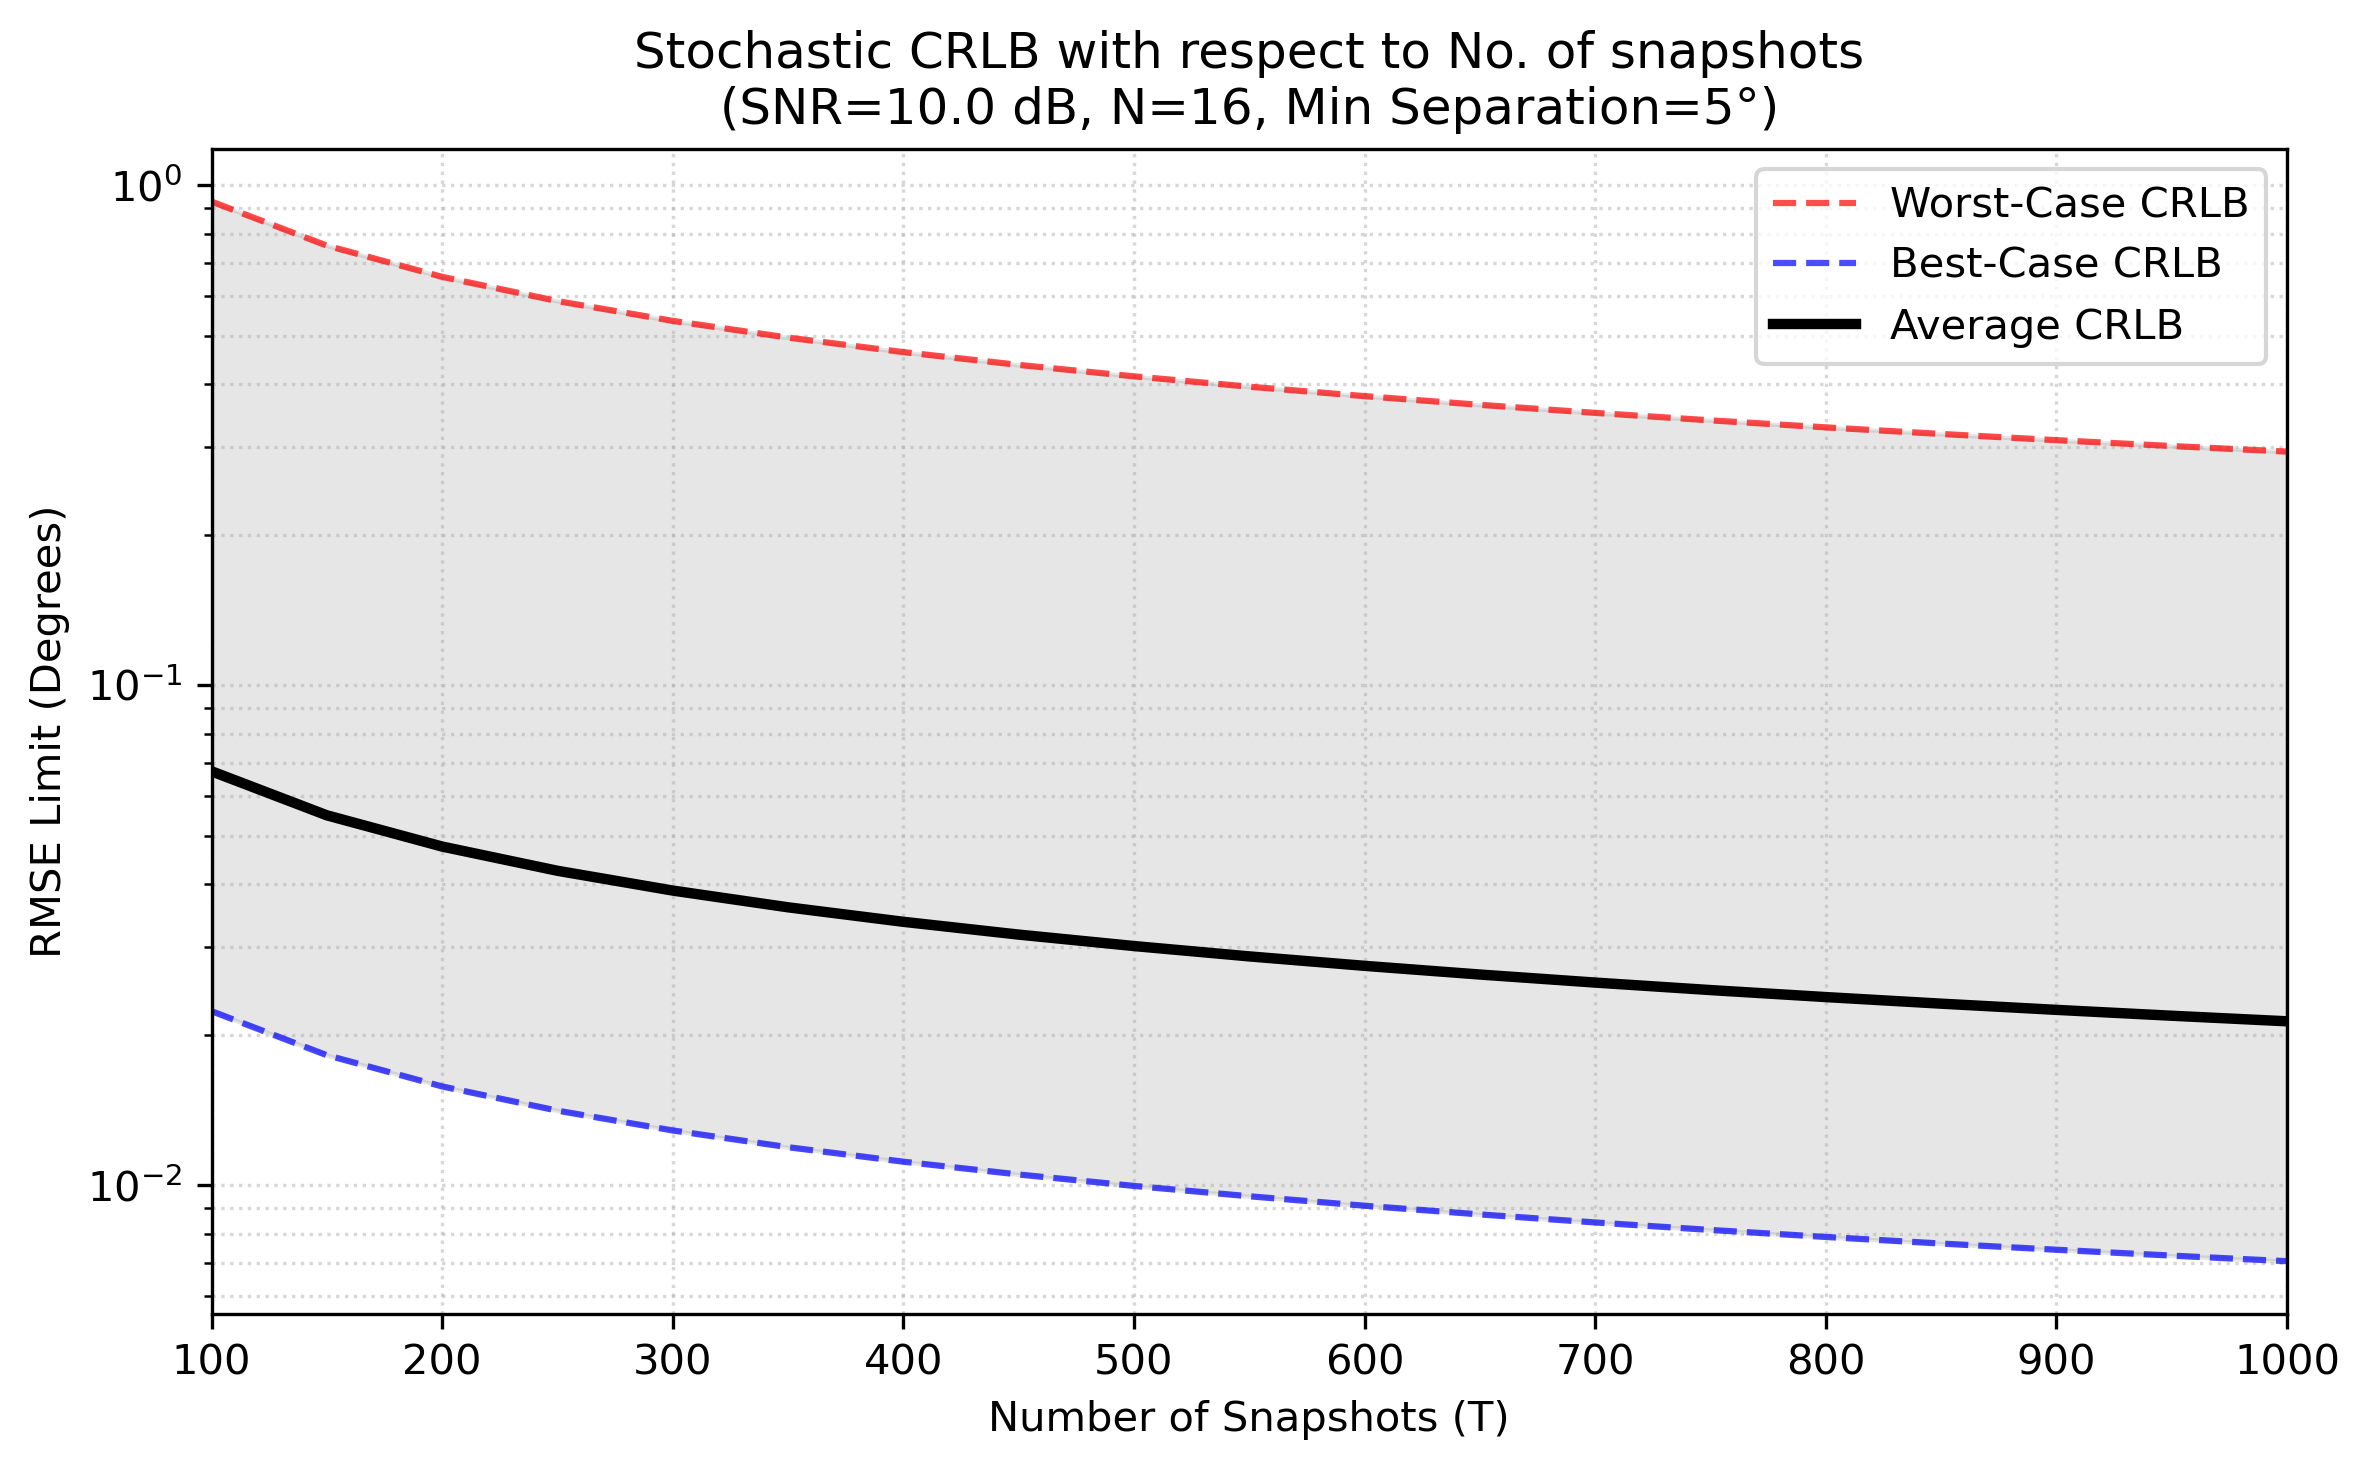

In [8]:
plt.figure(figsize=(8, 5), dpi=300); 

best_case_rmse = np.min(rmse_per_t, axis=1); 
worst_case_rmse = np.max(rmse_per_t, axis=1); 
average_rmse = np.sqrt(np.mean(crb_per_t, axis=1)); 

plt.semilogy(snapshot_range, worst_case_rmse, 'r--', linewidth=1.5, label='Worst-Case CRLB', alpha=0.7); 
plt.semilogy(snapshot_range, best_case_rmse, 'b--', linewidth=1.5, label='Best-Case CRLB', alpha=0.7); 
plt.semilogy(snapshot_range, average_rmse, 'k-', linewidth=2.5, label='Average CRLB'); 

for alpha_val in np.linspace(0.05, 0.3, 10):        # Gradient effect for the area in between
  plt.fill_between(snapshot_range, best_case_rmse, worst_case_rmse, color='gray', alpha=alpha_val/10); 

plt.title(f'Stochastic CRLB with respect to No. of snapshots\n(SNR={snr_db} dB, N={N}, Min Separation={ang_dist}°)'); 
plt.xlim([100,1000]); 
plt.xlabel('Number of Snapshots (T)'); plt.ylabel('RMSE Limit (Degrees)'); 
plt.grid(True, which="both", ls=":", alpha=0.5); 
plt.legend(loc='upper right'); 
plt.tight_layout(); 
plt.show(); 

Just as expected again, but this time we can see that the effect of increasing snapshot number fades in higher values. We can conclude that SNR plays a larger role in improving the lower bound; this is why there are many methods that attempt erasing noise. High snapshot is still useful especially for estimation and suppression of noise power in statistically stationary scenarios. However, its contribution to the amelioration of estimations usually come with high computation as a trade-off. 

### Antenna number's effect on CRLB

As a final test, we will analyze the size of the ULA by calculating CRLB values across the angle interval for antenna numbers $N=\{8,10,12,14,16,20,24,32,36,48,56,64\}$. The SNR is $10\text{ dB}$ and the snapshot number is $T=1000$. 

Increasing the number of antennas means increasing the aperture size, thus increasing the directivity of the overall array. It also means adding more data points to work with, therefore contributing to better noise/signal separation and noise estimation. For these reasons, we are hoping for better CRLB performance for larger ULAs.

In [11]:
N_range = [8,10,12,14,16,20,24,32,36,48,56,64]; 
snr_db = 10.; 

crb_per_n = []; 
for n in N_range: 
  print(f"Calculating N: {n}"); 
  P = generate_pos_1d_ula(n, d); 
  crb_vals = []; 
  for th1 in th1_scan: 

    th2_scan = np.arange(th1+ang_dist, ang_max+ang_res, ang_res); 
    for th2 in th2_scan: 
      angs_azim = [0]*K; 
      angs_elev = [th1, th2]; 
        
      # Calculate the CRB matrix
      crb_mat = calculate_stochastic_crb(P, angs_azim, angs_elev, snr_db, S_db, wl, T);  
      crb_vals.append(np.trace(crb_mat)/K); 
  
  crb_vals = np.array(crb_vals); 
  print(f"Calculation completed for N: {n}"); 
  crb_per_n.append(crb_vals); 

crb_per_n = np.array(crb_per_n); 
rmse_per_n = np.sqrt(crb_per_n); 

Calculating N: 8
Calculation completed for N: 8
Calculating N: 10
Calculation completed for N: 10
Calculating N: 12
Calculation completed for N: 12
Calculating N: 14
Calculation completed for N: 14
Calculating N: 16
Calculation completed for N: 16
Calculating N: 20
Calculation completed for N: 20
Calculating N: 24
Calculation completed for N: 24
Calculating N: 32
Calculation completed for N: 32
Calculating N: 36
Calculation completed for N: 36
Calculating N: 48
Calculation completed for N: 48
Calculating N: 56
Calculation completed for N: 56
Calculating N: 64
Calculation completed for N: 64


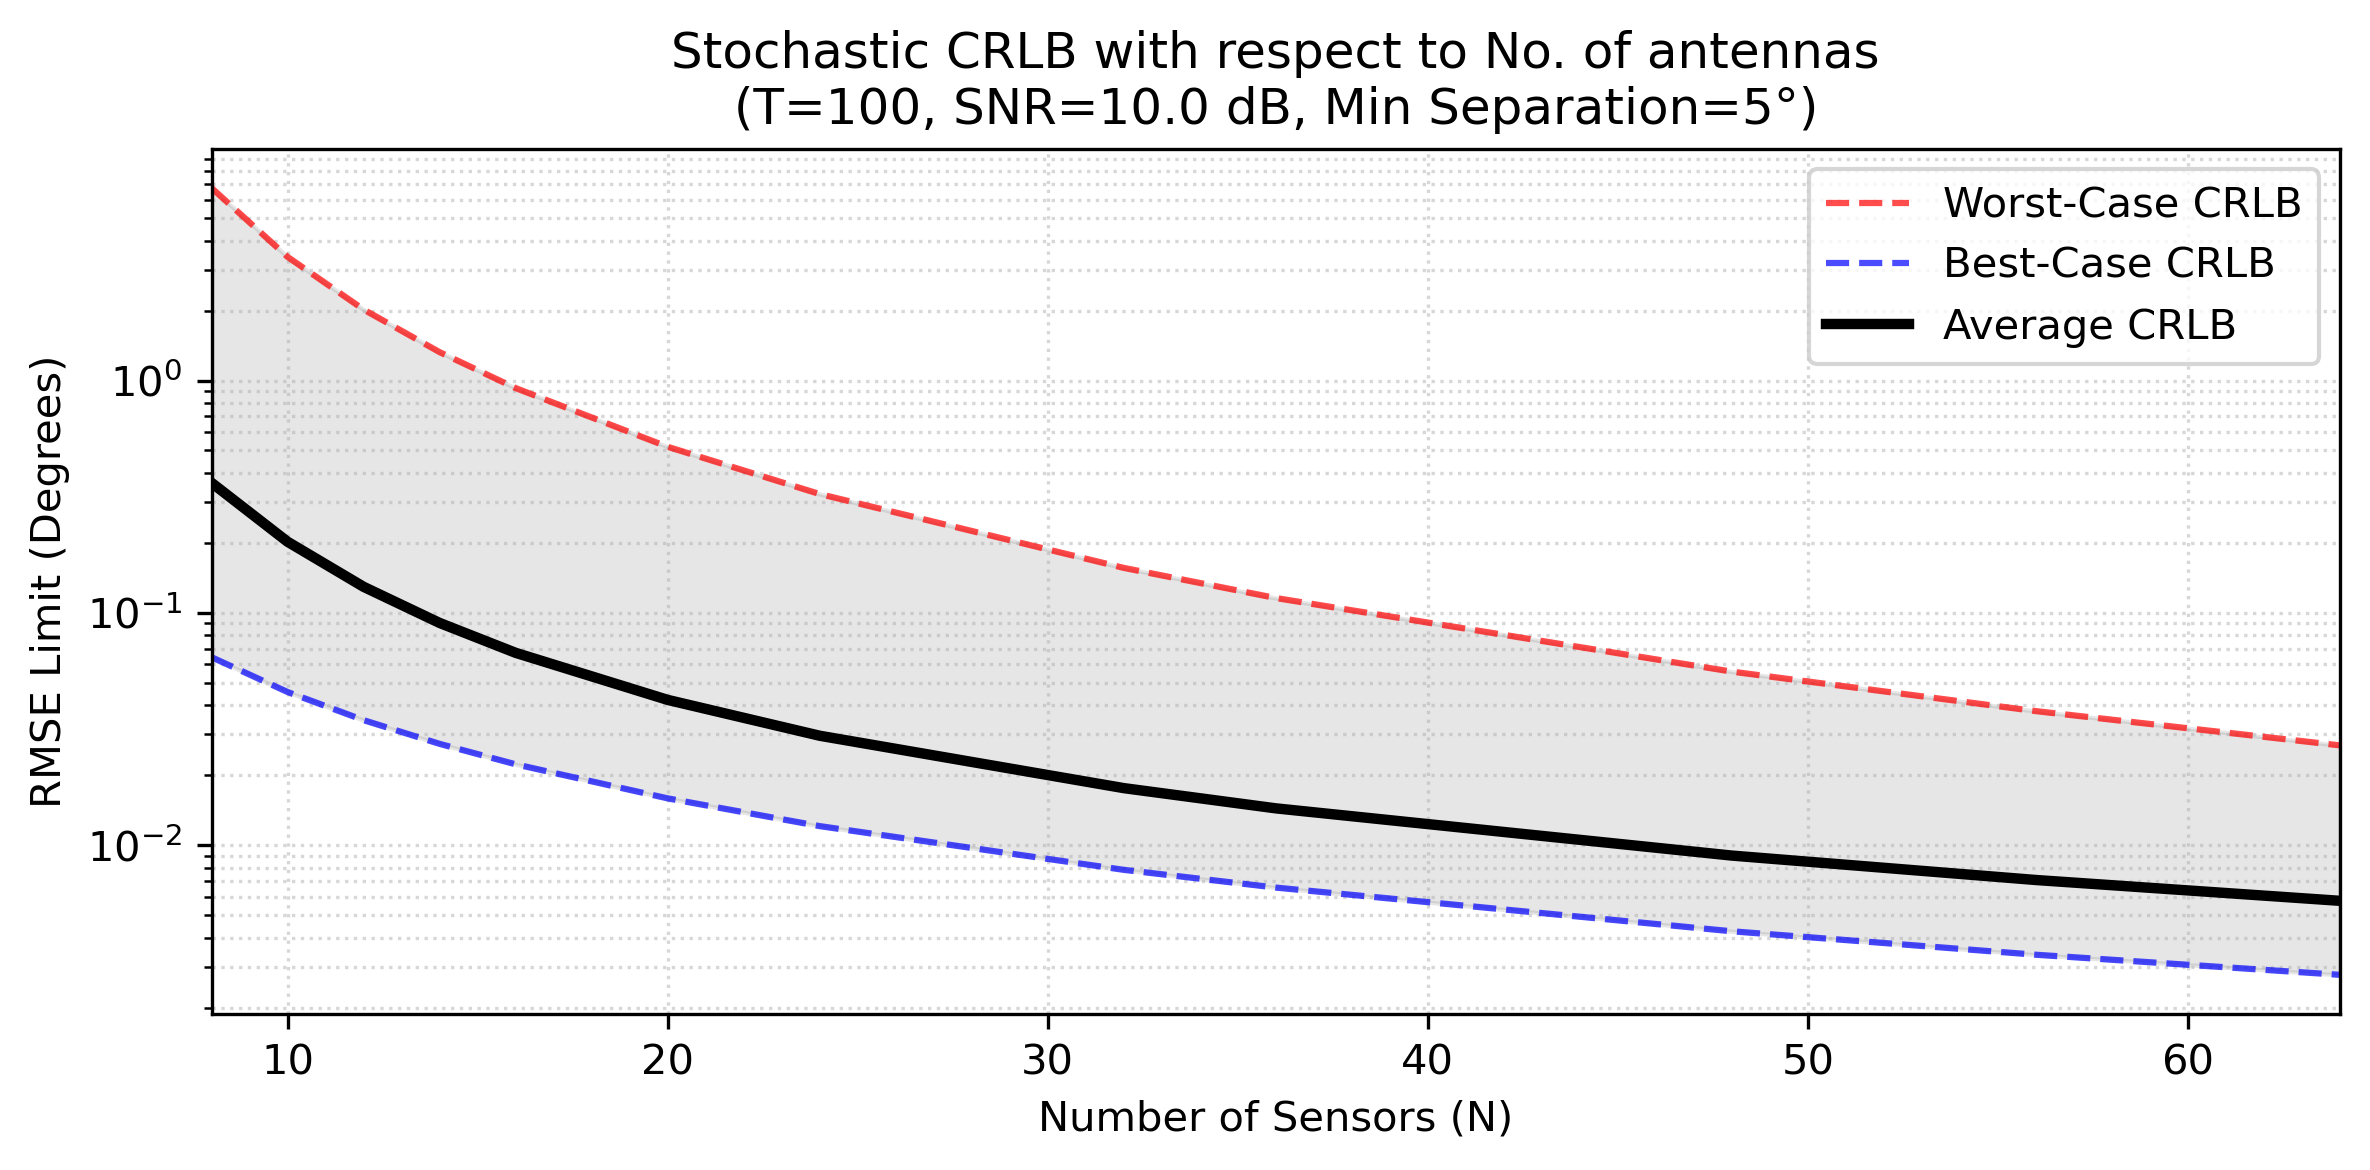

In [12]:
# Visualization with Gradient Area
plt.figure(figsize=(8,4), dpi=300); 

best_case_rmse = np.min(rmse_per_n, axis=1); 
worst_case_rmse = np.max(rmse_per_n, axis=1); 
average_rmse = np.sqrt(np.mean(crb_per_n, axis=1)); 

plt.semilogy(N_range, worst_case_rmse, 'r--', linewidth=1.5, label='Worst-Case CRLB', alpha=0.7); 
plt.semilogy(N_range, best_case_rmse, 'b--', linewidth=1.5, label='Best-Case CRLB', alpha=0.7); 
plt.semilogy(N_range, average_rmse, 'k-', linewidth=2.5, label='Average CRLB'); 

for alpha_val in np.linspace(0.05, 0.3, 10):        # Gradient effect for the area in between
  plt.fill_between(N_range, best_case_rmse, worst_case_rmse, color='gray', alpha=alpha_val/10); 

plt.title(f'Stochastic CRLB with respect to No. of antennas\n(T={T}, SNR={snr_db} dB, Min Separation={ang_dist}°)'); 
plt.xlabel('Number of Sensors (N)'); 
plt.ylabel('RMSE Limit (Degrees)'); 
plt.xlim([8, 64]); 
plt.grid(True, which="both", ls=":", alpha=0.5); 
plt.legend(loc='upper right'); 
plt.tight_layout(); 
plt.show(); 

Yet again, we observe the reduction of CRLB with increase in the number of antennas used. In addition, unlike the previous two test, we can also see the band between the lowest and the highest CRLB values shrinking for higher sensor number in the log-scale (this also happens with the increase of SNR but in a much smaller margin).

## References

[Theory of Statistical Estimation](https://www.cambridge.org/core/journals/mathematical-proceedings-of-the-cambridge-philosophical-society/article/theory-of-statistical-estimation/7A05FB68C83B36C0E91D42C76AB177D4). R.A. Fisher. *Mathematical Proceedings of the Cambridge Philosophical Society*. Volume 22. pages 700–725. 1925.

[Information and the accuracy attainable in the estimation of statistical parameters](https://www.ias.ac.in/article/fulltext/reso/020/01/0076-0090). C.R. Rao. *Bulletin of the Calcutta Mathematical Society*. Volume. Volume 37. pages 81–89. 1945.

[Chapters 32 — 34. Theory of Estimation](https://archive.org/details/in.ernet.dli.2015.223699/page/n485/mode/2up). H. Cramér. *Mathematical Methods of Statistics*. Chapters 32-34. pages 478-524. Princeton University Press. 1946.

[MUSIC, maximum likelihood, and Cramer-Rao bound](https://ieeexplore.ieee.org/abstract/document/17564?casa_token=lUL8w3PYGcQAAAAA:4tydBP_T4Edx7R7Bd8tXOWL96EG3vCop04QGWejE85b5M2Q4_M-ubsYJTgpRo4VjQCEGMyug-Q). P. Stoica and A. Nehorai. *IEEE Transactions on Acoustics, Speech, and Signal Processing*. Volume 37. Issue 5. pages 720 - 741. 31 May 1989.

[Performance study of conditional and unconditional direction-of-arrival estimation](https://ieeexplore.ieee.org/abstract/document/60109?casa_token=BE62pkj8jDYAAAAA:W2_61CPPSG20z0EuJ8G8TWaM1mDmdjCT1XzLJKyOsc8hWclXNTJh_mURHJrPk96wrGtnHRU_ug). P. Stoica and A. Nehorai. *IEEE Transactions on Acoustics, Speech, and Signal Processing*. Volume 38. Issue 10. pages 1783 - 1795. 31 October 1990.